# Simulate Populations with Asexual Reproduction
## Part 2

Previously we simulated the growth of our population, let's use algebra and what we know about the properties of the population of asexually reproducing unicellular organisms (and the like) to find an analytical solution.

## Change in Population Function

The change in population $\Delta P$ is the difference between the birth rate $B=P_tr$ and the death rate $D=P_td$ where $P_t$ is the current population at `period` $t$, $r$ is the `repro_chance`, and $d$ is the `death_chance`. We can write it as follows:

$$
\begin{equation*}
\begin{aligned}
\Delta P &= B-D &&\text{Substitute Pr for B and Pd for D}\\
\Delta P &= P_tr-P_td &&\text{Distributive Property}\\
\Delta P &= P_t(r-d) \\
\end{aligned}
\end{equation*}
$$

This function gives us the expected change of the population $\Delta P$ at the next time step, given the current population $P_t$.

Let's graph the function.

In [2]:
# Import required modules
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ipywidgets import interact, FloatSlider

In [3]:
def delta_p(population, repro_chance, death_chance):
    """ Calculate the expected change in population with constant repro_chance and a constant death_chance"""

    return population*(repro_chance - death_chance)

In [4]:
def make_plot(repro_chance, death_chance):
    
    #x-axis length
    domain=20
    
    # Generate plot data for the specified population domain
    population_change = [delta_p(p, repro_chance, death_chance) for p in range(domain)]

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Change in Population Function Graph",
        xlabel="Population",
        ylabel="Population Change",
        xlim=(0, domain),
        ylim=(0, 10)
    )

    # Set the axis tick marks and labels
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(.1))

    # Convert the graph spines so that they are centered on 0, 0 and don't show top or right boundaries
    ax.spines['left'].set_position(('data', 0))
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # plot data
    ax.plot(population_change)
    plt.show()

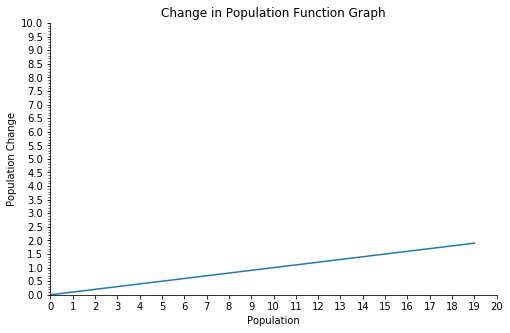

In [7]:


interact(make_plot, repro_chance=FloatSlider(value=0.2, min=0, max=5, step=0.1, continuous_update=False), death_chance=FloatSlider(value=0.1, min=0, max=5, step=0.1, continuous_update=False))

## Conclusion

The graph for $\Delta P$ is interactive. As you can see, when the `repro_chance` is greather than the `death_chance`, the population will grow. You will also notice that if the population is ever 0, the popuation growth is also 0. This would mean that the population can no longer rebound from 0, becoming extinct. Furthermore, when `repro_chance` equals the `death_chance`, the population growth will be 0 no matter how large the population currently is.  If the `death_chance` is ever greater than the `repro_chance`, the population will decline rapidly. 

This makes sense, each unicellular organism has the same chance of reproducing (dividing) before the end of each time step. If there are more protocells, there is a greater chance one or more will reproduce, causing the population to grow. This will be counteracted by the death chance, but as long as the reproduction chance is greater than the death chance, there will be more and more organisms dividing, causing a feedback loop.

NOTE: I think I need to mod. the simulation so that all currently living cells have a chance of dividing before having a chance of dying.